# Weather Condition Classification — End-to-End Machine Learning Portfolio Project

### Predicting weather conditions from historical meteorological observations

**Project type:** Multiclass Classification · Feature Engineering · Feature Selection · Model Comparison

This notebook presents a complete machine-learning workflow for predicting the observed **weather condition** from historical weather measurements. The workflow includes chronological feature engineering, lag variables, cyclical time encoding, multiple feature-selection techniques, six classification algorithms, and model comparison.



## 1. Project Overview

### Objective

Build a multiclass machine-learning system that learns the relationship between meteorological measurements and the recorded weather **Condition**.

### Core questions

1. How much predictive information is contained in current weather measurements and historical lagged observations?
2. Which features remain useful after combining variance, correlation, mutual information, and Lasso-based selection?
3. How do different classification algorithms compare on the same feature set?

### Machine-learning workflow

**Raw weather data** → **date/time engineering** → **lag features** → **data cleaning** → **feature selection** → **train/test split** → **classification models** → **model comparison**

### How to Use This Notebook

Run the cells from top to bottom. Each modeling section is intentionally separated into small, readable cells, and every code cell has a Markdown explanation immediately before it. This layout is suitable for Google Colab screenshots, GitHub review, and LinkedIn portfolio sharing.


## 2. Dataset and Input Assumptions

The source file is an Excel workbook containing **77,341 observations and 10 original columns**.

Important fields used by the pipeline include:

- `DATE` — observation date
- `Time` — observation time
- `Condition` — target weather condition
- temperature, wind speed, humidity, pressure, and visibility variables — predictive inputs

The notebook assumes the Excel workbook is stored at the Google Drive path configured below. Update `DATA_PATH` when running outside the original Colab environment.

In [4]:
# ============================================================
# 3. Imports and Configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dateutil import parser

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = "/content/drive/MyDrive/weather-condition-classification/data/Projectdata.xlsx"

# Performance-oriented settings for a large tabular dataset.
XGB_N_JOBS = -1
RF_N_JOBS = -1

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load the Data

The first step is to load the Excel workbook and verify that the columns required for the project are available. Keeping this validation near the beginning makes failures easier to diagnose when the notebook is reused with another file.

In [5]:
# ============================================================
# 4. Data Loading and Validation
# ============================================================
df = pd.read_excel(DATA_PATH)
print(f"Initial DataFrame shape: {df.shape}")

required_columns = ["Time", "DATE", "Condition"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

display(df.head())

Initial DataFrame shape: (77341, 10)


,Time,Temperature(Â°C),Condition,Wind Speed(km/h),Humidity,Pressure(mbar),Visibility,Year,Month,DATE
0,00:29,3,Fog.,4,0.81,1022,1,2020,1,"Wed, 1 Jan"
1,00:55:00,3,Fog.,6,0.81,1022,1,2020,1,"Wed, 1 Jan"
2,01:25:00,3,Fog.,6,0.81,1022,1,2020,1,"Wed, 1 Jan"
3,01:55:00,3,Fog.,9,0.81,1022,1,2020,1,"Wed, 1 Jan"
4,02:25:00,3,Fog.,7,0.81,1021,1,2020,1,"Wed, 1 Jan"


## 4. Time Feature Engineering

Weather changes with the time of day. Instead of keeping the raw time string, the pipeline extracts the **hour** so the model can learn intraday patterns.

Missing times are interpreted as hour `0` (midnight) to keep the feature numeric and model-ready.

In [6]:
# ============================================================
# 5. Time Feature Engineering
# ============================================================
time_hms = pd.to_datetime(
    df["Time"].astype(str),
    format="%H:%M:%S",
    errors="coerce",
)

time_hm = pd.to_datetime(
    df["Time"].astype(str),
    format="%H:%M",
    errors="coerce",
)

df["Time"] = time_hms.fillna(time_hm)
df["hour"] = df["Time"].dt.hour.fillna(0).astype(int)

print("Hour feature created successfully.")

Hour feature created successfully.


## 5. Date and Day-of-Week Features

The original date column may contain mixed Excel/string representations. A safe parser is used so invalid values become `NaT` instead of breaking the pipeline.

The day of week is mapped to a numerical representation from **1 (Monday) to 7 (Sunday)**.

In [7]:
# ============================================================
# 6. Date and Day-of-Week Feature Engineering
# ============================================================
def safe_parse(value):
    """Safely parse Excel/string dates without crashing on invalid values."""
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (pd.Timestamp, np.datetime64)):
        return pd.to_datetime(value, errors="coerce")

    try:
        return parser.parse(str(value), fuzzy=True)
    except (ValueError, TypeError, OverflowError):
        return pd.NaT


df["date"] = df["DATE"].apply(safe_parse)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["Day"] = df["date"].dt.day_name()
weekday_map = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7,
}
df["Day"] = df["Day"].map(weekday_map)
df["Day of Week"] = df["Day"]

print("Day of Week created successfully.")

Day of Week created successfully.


## 6. Simplify the Target Labels

The raw `Condition` values contain punctuation such as trailing periods. The labels are normalized before encoding so visually equivalent categories are treated consistently.

In [8]:
# ============================================================
# 7. Condition Simplification
# ============================================================
df["Condition"] = (
    df["Condition"]
    .astype("string")
    .str.split(".")
    .str[0]
    .str.strip()
    .add(".")
)

print("Condition column simplified.")

Condition column simplified.


## 7. Chronological Ordering and Lag Features

Lag features are one of the most important parts of this project.

A lag represents a previous observation—for example:

- `Lag_1_Temperature` → previous observation's temperature
- `Lag_24_Pressure` → pressure 24 observations earlier
- `Lag_720_Pressure` → pressure 720 observations earlier

The data is sorted chronologically **before** shifting so each lag actually refers to an earlier observation rather than simply an earlier row in an unsorted spreadsheet.

In [9]:
# ============================================================
# 8. Sort Chronologically and Create Lag Features
# ============================================================
df = df.sort_values(["date", "Time"], kind="stable").reset_index(drop=True)


def create_lag_features(df_in, lag_mapping):
    df_out = df_in.copy()

    for feature, lags in lag_mapping.items():
        if feature not in df_out.columns:
            print(f"Warning: '{feature}' not found; skipping lag creation.")
            continue

        df_out[feature] = pd.to_numeric(df_out[feature], errors="coerce")

        for lag in lags:
            df_out[f"Lag_{lag}_{feature}"] = df_out[feature].shift(lag)

    return df_out


feature_lag_mapping = {
    "Temperature(Â°C)": [1, 3, 6, 24],
    "Wind Speed(km/h)": [1, 3, 6],
    "Humidity": [24, 168],
    "Pressure(mbar)": [1, 24, 720],
    "Visibility": [1, 3],
}

features_for_interpolation = [
    feature for feature in feature_lag_mapping if feature in df.columns
]

for feature in features_for_interpolation:
    df[feature] = pd.to_numeric(df[feature], errors="coerce")

if features_for_interpolation:
    df[features_for_interpolation] = (
        df[features_for_interpolation]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

df = create_lag_features(df, feature_lag_mapping)

max_lag = max(
    (lag for lags in feature_lag_mapping.values() for lag in lags),
    default=0,
)

if max_lag > 0 and len(df) > max_lag:
    df = df.iloc[max_lag:].reset_index(drop=True)

print(f"Maximum lag used: {max_lag}")

Maximum lag used: 720


## 8. Cyclical Time Encoding and Feature Cleanup

Hour `23` and hour `0` are numerically far apart (`23 - 0 = 23`), even though they are adjacent points in a daily cycle.

To represent time cyclically, the hour is transformed into:

- `hour_sin`
- `hour_cos`

This places adjacent hours close together in a circular feature space.

Redundant metadata columns are then removed before machine learning.

In [10]:
# ============================================================
# 9. Cyclical Time Features + Cleanup
# ============================================================
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)

df.drop(columns=["hour"], inplace=True)

columns_to_drop = ["Time", "date", "DATE", "Day", "Year", "Month"]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped redundant columns: {columns_to_drop}")
print(f"DataFrame shape after lag features and cleanup: {df.shape}")

Dropped redundant columns: ['Time', 'date', 'DATE', 'Day', 'Year', 'Month']
DataFrame shape after lag features and cleanup: (76621, 23)


## 9. Numeric Conversion and Missing-Value Handling

Scikit-learn feature-selection methods expect numerical predictors. Weather columns are therefore coerced to numeric values, and missing observations are filled using interpolation followed by forward/backward filling.

A final numeric check is performed before feature selection so a hidden `NaN` does not cause a later model to fail.

In [11]:
# ============================================================
# 10. Numeric Conversion and NaN Handling
# ============================================================
for col in df.columns:
    if col != "Condition":
        df[col] = pd.to_numeric(df[col], errors="coerce")

lagged_features_for_nan_fill = [
    col for col in df.columns
    if "Lag_" in col or col in feature_lag_mapping
]

for feature in lagged_features_for_nan_fill:
    if feature in df.columns:
        df[feature] = df[feature].ffill().bfill()

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col] = df[col].fillna(0 if pd.isna(mean_value) else mean_value)

print(f"Remaining numeric NaNs: {int(df[numeric_columns].isna().sum().sum())}")

Remaining numeric NaNs: 0


## 10. Pressure Cleaning

Pressure readings of `0 mbar` are treated as invalid values. They are replaced with missing values, interpolated, filled where necessary, and then min-max scaled.

This keeps pressure-related inputs in a stable numerical range before downstream algorithms are trained.

In [12]:
# ============================================================
# 11. Pressure Cleaning and Scaling
# ============================================================
pressure_columns = [
    "Lag_1_Pressure(mbar)",
    "Lag_24_Pressure(mbar)",
    "Lag_720_Pressure(mbar)",
    "Pressure(mbar)",
]

for col in pressure_columns:
    if col not in df.columns:
        continue

    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].interpolate(method="linear", limit_direction="both")
    df[col] = df[col].bfill().ffill()

    col_min = df[col].min()
    col_max = df[col].max()

    if pd.notna(col_min) and pd.notna(col_max) and col_max != col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    elif pd.notna(col_min):
        df[col] = 0.0

print("Pressure columns handled and scaled.")

Pressure columns handled and scaled.


## 11. Handle Singleton Classes Before Model Training

The completed experiment revealed three weather-condition classes with only **one observation each**. A class with one sample cannot be represented in both training and test data, so a valid stratified classification experiment is impossible while those singleton classes remain.

For the modeling experiment, only classes with at least **2 observations** are retained. This removes the minimum amount of data necessary to make stratified splitting valid. The excluded classes are reported explicitly so the decision remains transparent.


In [13]:
# ============================================================
# 12. Remove Singleton Target Classes + Encode Target
# ============================================================
condition_counts_raw = df["Condition"].value_counts().sort_values()
rare_condition_names = condition_counts_raw[condition_counts_raw < 2].index.tolist()

if rare_condition_names:
    print("Removing singleton condition classes for robust stratified evaluation:")
    for condition_name in rare_condition_names:
        print(f"  - {condition_name}: {int(condition_counts_raw[condition_name])} sample")

    df = df[~df["Condition"].isin(rare_condition_names)].copy()
    df.reset_index(drop=True, inplace=True)
else:
    print("No singleton classes found.")

# Re-encode after rare-class removal so labels are contiguous: 0 ... n_classes-1.
label_encoder = LabelEncoder()
df["Condition"] = label_encoder.fit_transform(df["Condition"].astype(str))

print(f"Rows remaining after singleton removal: {len(df):,}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print("Classes:", list(label_encoder.classes_))

class_distribution = (
    df["Condition"]
    .value_counts()
    .rename_axis("Condition")
    .reset_index(name="Samples")
    .sort_values("Samples")
)

display(class_distribution.head(10))


Removing singleton condition classes for robust stratified evaluation:
  - Refreshingly cool.: 1 sample
  - Sandstorm.: 1 sample
  - Hail.: 1 sample
Rows remaining after singleton removal: 76,618
Number of classes: 31
Classes: ['0.', 'Broken clouds.', 'Clear.', 'Cool.', 'Dense fog.', 'Drizzle.', 'Duststorm.', 'Extremely hot.', 'Fog.', 'Haze.', 'Hot.', 'Light fog.', 'Light rain.', 'Mild.', 'More clouds than sun.', 'Mostly cloudy.', 'Overcast.', 'Partly cloudy.', 'Partly sunny.', 'Passing clouds.', 'Pleasantly warm.', 'Quite cool.', 'Rain showers.', 'Rain.', 'Scattered clouds.', 'Smoke.', 'Strong thunderstorms.', 'Sunny.', 'Thundershowers.', 'Thunderstorms.', 'Warm.']


,Condition,Samples
30,16,5
29,10,9
28,4,10
27,26,15
26,20,17
25,22,20
24,21,22
23,13,22
22,11,27
20,30,29


## 12. Feature Selection Strategy

Four complementary techniques are used:

| Method | Purpose |
|---|---|
| **Variance Threshold** | Removes features with very little variation |
| **Correlation** | Identifies features associated with the encoded target |
| **Mutual Information** | Captures potentially nonlinear dependency with the target |
| **Lasso** | Selects variables with non-zero regularized coefficients |

The final feature set is the **intersection** of the selected sets. This is deliberately conservative: a feature must receive support from all four selection methods to be retained.

In [14]:
# ============================================================
# 13. Feature Selection Setup
# ============================================================
bf = df.copy()
X_all = df.drop(columns=["Condition"]).select_dtypes(include=np.number)
y_all = df["Condition"]

if X_all.empty:
    raise ValueError("No numeric predictor columns are available for feature selection.")

print(f"Candidate predictor count: {X_all.shape[1]}")

Candidate predictor count: 22


### 12.1 Variance Threshold

Features with variance below `0.01` are removed because they provide very little variation across the dataset.

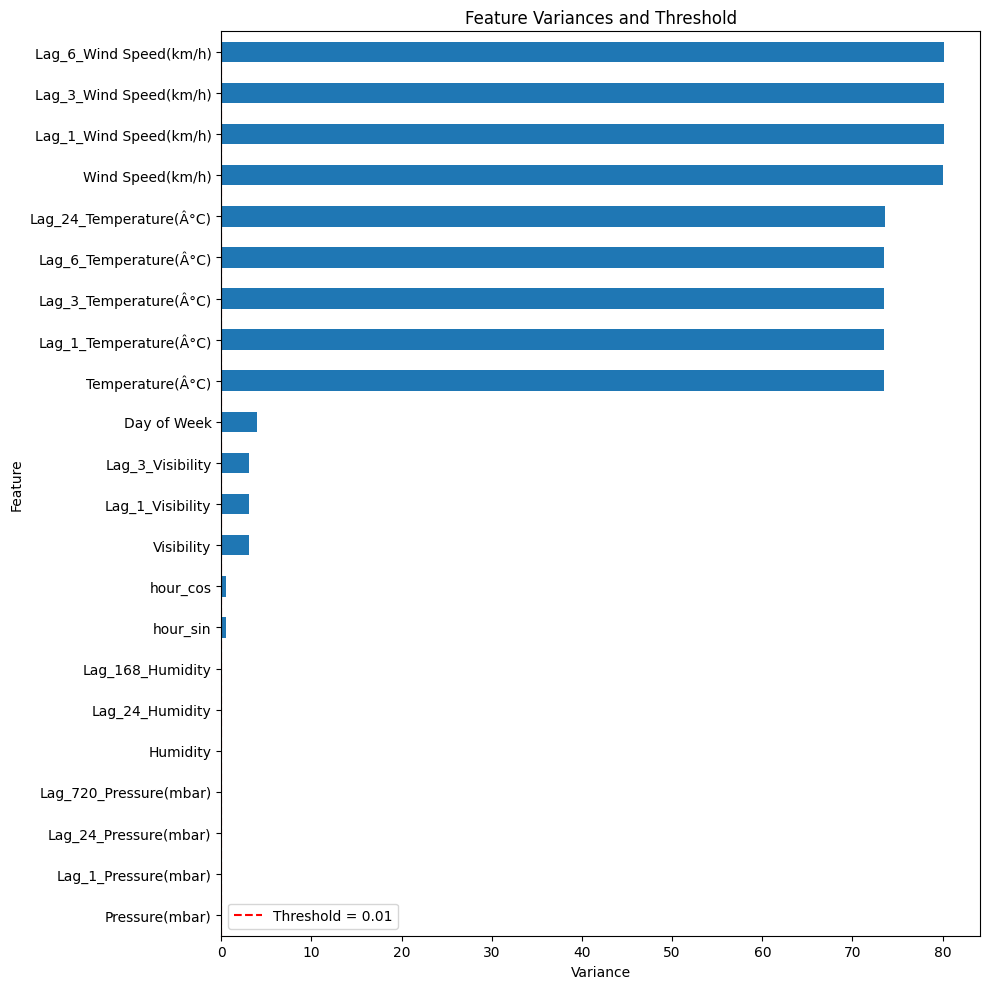

Variance threshold selected features count: 22


In [15]:
# ============================================================
# 14. Variance Threshold Selection
# ============================================================
selector = VarianceThreshold(threshold=0.01)

try:
    selector.fit(X_all)
    selected_features_V = X_all.columns[selector.get_support()]

    # Visualization of feature variances
    feature_variances = pd.Series(selector.variances_, index=X_all.columns)
    feature_variances_sorted = feature_variances.sort_values(ascending=True)

    plt.figure(figsize=(10, 10))
    feature_variances_sorted.plot(kind='barh')
    plt.axvline(x=selector.threshold, color='r', linestyle='--', label=f'Threshold = {selector.threshold}')
    plt.title('Feature Variances and Threshold')
    plt.xlabel('Variance')
    plt.ylabel('Feature')
    plt.legend()
    plt.tight_layout()
    plt.show()

except ValueError:
    selected_features_V = pd.Index(X_all.columns)

print(f"Variance threshold selected features count: {len(selected_features_V)}")

### 12.2 Correlation Screening

Pearson correlation with the encoded target is used as a simple linear screening step. Features with absolute correlation greater than `0.10` are retained for the intersection stage.

> **Interpretation note:** because `Condition` is multiclass, correlation with integer-encoded labels is a screening heuristic rather than a complete measure of class dependence. Mutual information is included to complement this limitation.

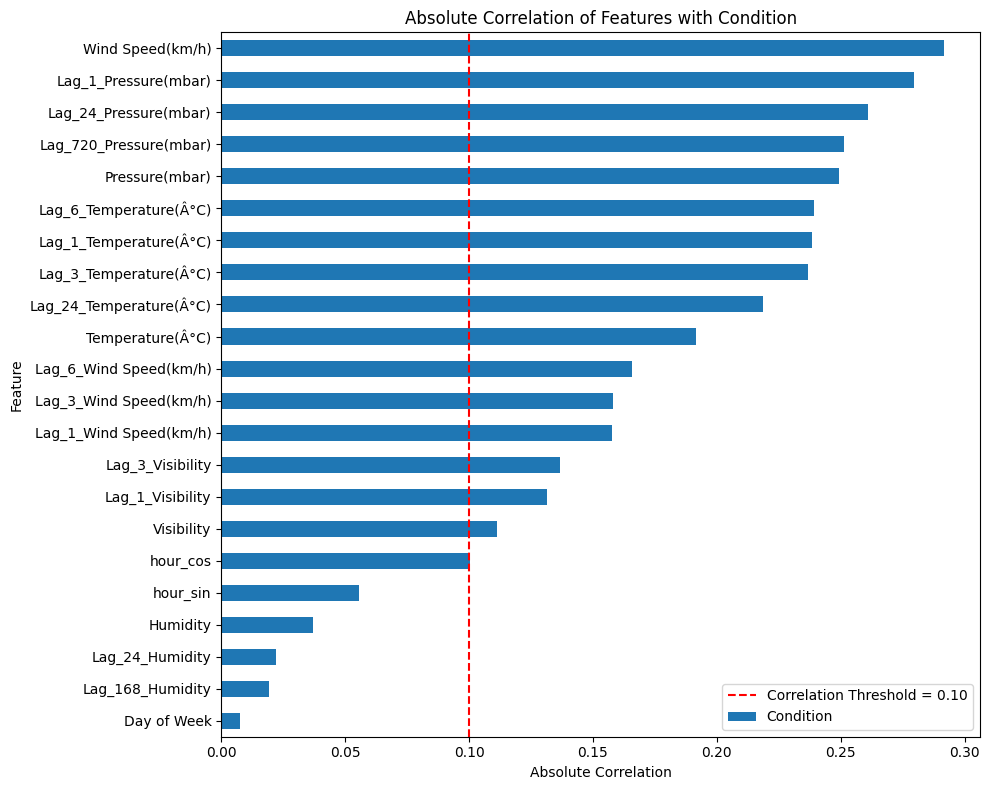

Correlation selected features count: 17


In [16]:
# ============================================================
# 15. Correlation Selection
# ============================================================
correlation_matrix = bf.select_dtypes(include=np.number).corr()

if "Condition" in correlation_matrix.columns:
    condition_correlation = correlation_matrix["Condition"].drop(
        labels=["Condition"],
        errors="ignore",
    )

    # Visualization of feature correlations
    condition_correlation_abs = condition_correlation.abs().sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    condition_correlation_abs.plot(kind='barh')
    plt.axvline(x=0.10, color='r', linestyle='--', label='Correlation Threshold = 0.10')
    plt.title('Absolute Correlation of Features with Condition')
    plt.xlabel('Absolute Correlation')
    plt.ylabel('Feature')
    plt.legend()
    plt.tight_layout()
    plt.show()

    highly_correlated_features = condition_correlation[
        (condition_correlation > 0.10) | (condition_correlation < -0.10)
    ].index.tolist()
else:
    highly_correlated_features = []

print(f"Correlation selected features count: {len(highly_correlated_features)}")

### 12.3 Mutual Information

Mutual information can detect nonlinear dependence between a predictor and the target. Features with a mutual-information score above `0.01` are retained.

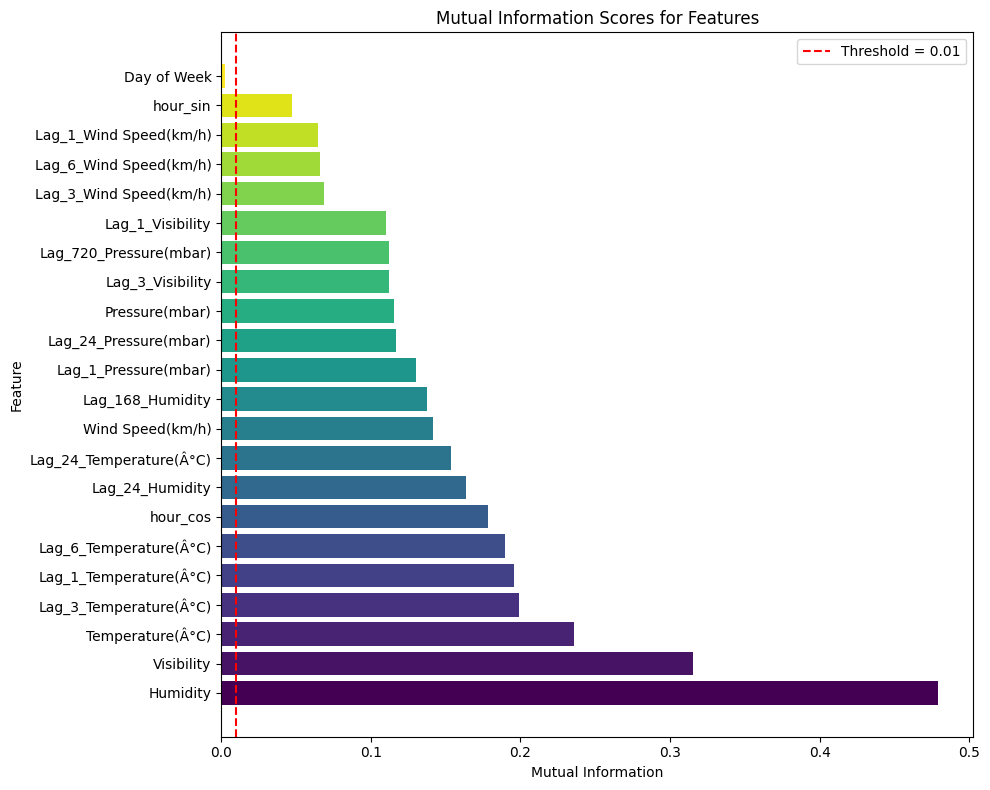

Mutual Information selected features count: 21


,Feature,Mutual Information
2,Humidity,0.478893
4,Visibility,0.315298
0,Temperature(Â°C),0.235953
7,Lag_3_Temperature(Â°C),0.199061
6,Lag_1_Temperature(Â°C),0.195796
8,Lag_6_Temperature(Â°C),0.189990
21,hour_cos,0.178093
13,Lag_24_Humidity,0.163813
9,Lag_24_Temperature(Â°C),0.153739
1,Wind Speed(km/h),0.141497


In [17]:
# ============================================================
# 16. Mutual Information Selection
# ============================================================
mi_scores = mutual_info_classif(
    X_all,
    y_all,
    discrete_features="auto",
    random_state=RANDOM_STATE,
)

mi_scores_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Mutual Information": mi_scores,
}).sort_values("Mutual Information", ascending=False)

threshold_mi = 0.01
selected_features_MF = mi_scores_df.loc[
    mi_scores_df["Mutual Information"] > threshold_mi,
    "Feature",
].tolist()

# Visualization of mutual information scores
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(mi_scores_df)))
plt.barh(mi_scores_df["Feature"], mi_scores_df["Mutual Information"], color=colors)
plt.axvline(x=threshold_mi, color='r', linestyle='--', label=f'Threshold = {threshold_mi}')
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information Scores for Features")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mutual Information selected features count: {len(selected_features_MF)}")
display(mi_scores_df.head(10))

### 12.4 Lasso Selection

Lasso is retained to match the project's original methodology. Predictors are standardized first because L1 regularization is sensitive to feature scale.

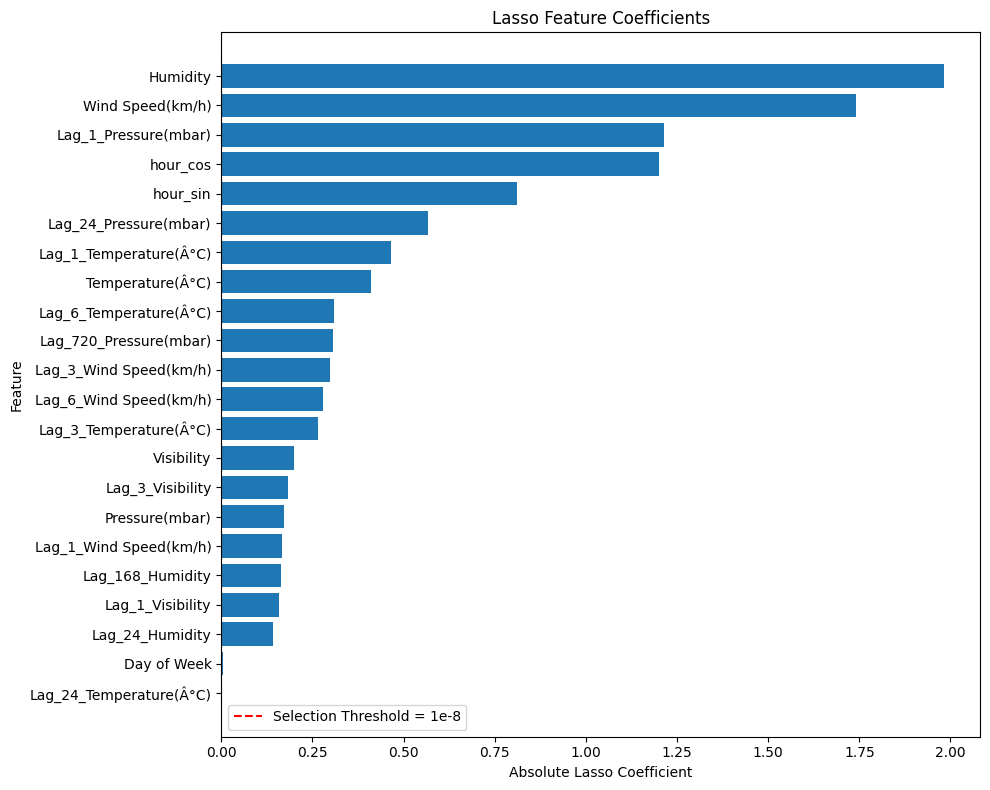

Lasso selected features count: 21


In [18]:
# ============================================================
# 17. Lasso Selection
# ============================================================
scaler_lasso = StandardScaler()
X_scaled_lasso = scaler_lasso.fit_transform(X_all)

lasso = Lasso(
    alpha=0.01,
    random_state=RANDOM_STATE,
    max_iter=10000,
)

lasso.fit(X_scaled_lasso, y_all)

selected_features_L = X_all.columns[np.abs(lasso.coef_) > 1e-8]

# Visualization of Lasso coefficients
lasso_coef_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Coefficient": np.abs(lasso.coef_),
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(lasso_coef_df["Feature"], lasso_coef_df["Coefficient"])
plt.axvline(x=1e-8, color='r', linestyle='--', label=f'Selection Threshold = 1e-8')
plt.xlabel("Absolute Lasso Coefficient")
plt.ylabel("Feature")
plt.title("Lasso Feature Coefficients")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lasso selected features count: {len(selected_features_L)}")

### 12.5 Final Predictive Feature Set

The original notebook used the **intersection** of all four selectors, producing 16 features. That is useful as a conservative research subset, but it can also remove complementary predictors that tree-based models can use effectively.

For the performance experiment, the notebook keeps the **22 variance-screened features** and ranks them by mutual information. This is less restrictive while still removing near-constant predictors. The original 16-feature intersection is preserved as a reference so the methodology remains reproducible.


Original 4-way intersection: 16 features
Performance-oriented feature set: 22 features
Selected features:
  - Humidity
  - Visibility
  - Temperature(Â°C)
  - Lag_3_Temperature(Â°C)
  - Lag_1_Temperature(Â°C)
  - Lag_6_Temperature(Â°C)
  - hour_cos
  - Lag_24_Humidity
  - Lag_24_Temperature(Â°C)
  - Wind Speed(km/h)
  - Lag_168_Humidity
  - Lag_1_Pressure(mbar)
  - Lag_24_Pressure(mbar)
  - Pressure(mbar)
  - Lag_3_Visibility
  - Lag_720_Pressure(mbar)
  - Lag_1_Visibility
  - Lag_3_Wind Speed(km/h)
  - Lag_6_Wind Speed(km/h)
  - Lag_1_Wind Speed(km/h)
  - hour_sin
  - Day of Week


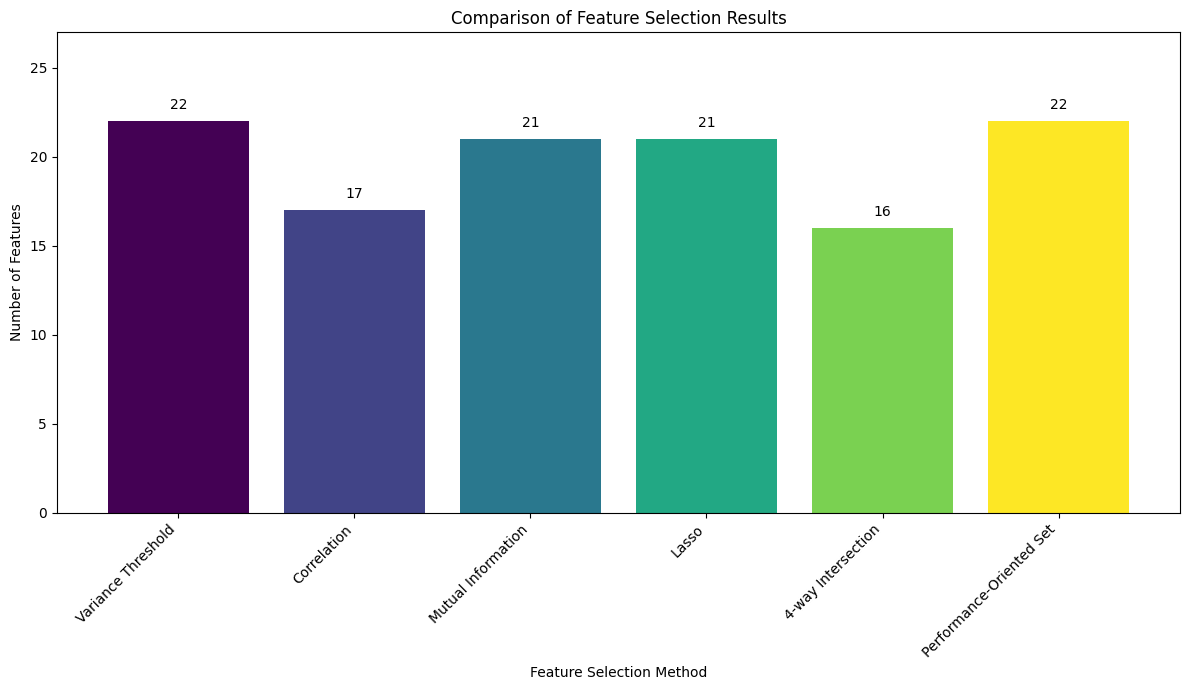

In [19]:
# ============================================================
# 18. Final Predictive Feature Set
# ============================================================
variance_set = set(selected_features_V)
correlated_set = set(highly_correlated_features)
mutual_info_set = set(selected_features_MF)
lasso_selected_set = set(selected_features_L)

# Original conservative intersection (kept for reference).
common_features = mutual_info_set.intersection(
    lasso_selected_set,
    correlated_set,
    variance_set,
)

if not common_features:
    fallback_features = (
        mutual_info_set.intersection(variance_set)
        or lasso_selected_set.intersection(variance_set)
        or correlated_set.intersection(variance_set)
    )
    common_features = fallback_features or variance_set or set(X_all.columns)

# Performance-oriented set:
# keep all low-variance-screened predictors, then rank by MI.
mi_ranked_variance_features = [
    feature
    for feature in mi_scores_df["Feature"].tolist()
    if feature in variance_set
]

features = mi_ranked_variance_features or sorted(variance_set) or list(X_all.columns)

print(f"Original 4-way intersection: {len(common_features)} features")
print(f"Performance-oriented feature set: {len(features)} features")
print("Selected features:")
for feature in features:
    print(f"  - {feature}")

# Visualization of Feature Set Sizes
selection_counts = {
    "Variance Threshold": len(variance_set),
    "Correlation": len(correlated_set),
    "Mutual Information": len(mutual_info_set),
    "Lasso": len(lasso_selected_set),
    "4-way Intersection": len(common_features),
    "Performance-Oriented Set": len(features)
}

plt.figure(figsize=(12, 7))
methods = list(selection_counts.keys())
counts = list(selection_counts.values())
colors = [plt.cm.get_cmap('viridis')(i) for i in np.linspace(0, 1, len(methods))]

bars = plt.bar(methods, counts, color=colors)
plt.xlabel("Feature Selection Method")
plt.ylabel("Number of Features")
plt.title("Comparison of Feature Selection Results")
plt.ylim(0, X_all.shape[1] + 5)
plt.xticks(rotation=45, ha="right")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 13. Stratified Train/Test Split

After singleton classes have been removed, every remaining class has at least two observations. The dataset can therefore be split using **stratification**, preserving class proportions in the training and testing subsets.

The test set remains completely unseen during model fitting and evaluation.


In [20]:
# ============================================================
# 19. Stratified Train/Test Split
# ============================================================
X = df[features].copy().astype(np.float32)
y = df["Condition"].copy()

class_counts = y.value_counts()

if class_counts.min() < 2:
    raise ValueError("A singleton class remains; stratified splitting is unsafe.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Stratified train/test split enabled.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Training classes: {y_train.nunique()}")
print(f"Testing classes: {y_test.nunique()}")


Stratified train/test split enabled.
X_train shape: (61294, 22)
X_test shape: (15324, 22)
Training classes: 31
Testing classes: 31


## 14. Classification Models

Six supervised learning algorithms are compared using the **same selected features** and the **same train/test split**:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)
5. Multilayer Perceptron (Neural Network)
6. XGBoost

Scaling is applied through pipelines for algorithms that are sensitive to feature magnitude.

In [21]:
# ============================================================
# 20. Model Definitions — Tuned Configurations
# ============================================================
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=2.0,
            max_iter=3000,
            random_state=RANDOM_STATE,
        ),
    ),

    # More trees + a larger feature fraction can improve tabular accuracy.
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_features=0.8,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=RF_N_JOBS,
    ),

    # Keep the original RBF SVM but give it more cache and a moderate C.
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(
            C=2.0,
            kernel="rbf",
            gamma="scale",
            cache_size=2048,
        ),
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            n_jobs=-1,
        ),
    ),

    "Neural Network": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            alpha=1e-4,
            learning_rate_init=0.001,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=20,
            max_iter=500,
            random_state=RANDOM_STATE,
        ),
    ),
}


## 15. Train and Evaluate the Models

The model stage uses the same stratified split and the expanded predictive feature set.

### Why XGBoost now works

The target was re-encoded **after** singleton classes were removed, producing contiguous labels such as `0, 1, 2, ..., K-1`. This is exactly the label structure expected by multiclass XGBoost, so the earlier error involving a missing class ID is eliminated.

XGBoost is also configured with histogram-based tree construction (`tree_method="hist"`) and tuned depth, learning rate, subsampling, and column sampling for large tabular data.


In [22]:
# ============================================================
# 21. Train and Evaluate Models
# ============================================================
model_accuracies = {}
model_predictions = {}
trained_models = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        model_accuracies[name] = accuracy
        model_predictions[name] = y_pred
        trained_models[name] = model

        print(f"{name} Accuracy: {accuracy:.4f}")

    except Exception as exc:
        print(f"{name} failed: {exc}")


# ============================================================
# Tuned XGBoost
# ============================================================
try:
    n_classes = y_train.nunique()

    xgb_model = XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        n_estimators=700,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=2,
        subsample=0.90,
        colsample_bytree=0.90,
        gamma=0.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        max_bin=256,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=XGB_N_JOBS,
    )

    xgb_model.fit(
        X_train,
        y_train,
        verbose=False,
    )

    xgb_pred_proba = xgb_model.predict_proba(X_test)
    xgb_pred = np.argmax(xgb_pred_proba, axis=1).astype(int)

    xgb_accuracy = accuracy_score(y_test, xgb_pred)

    model_accuracies["XGBoost"] = xgb_accuracy
    model_predictions["XGBoost"] = xgb_pred
    trained_models["XGBoost"] = xgb_model

    print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

except Exception as exc:
    print(f"XGBoost failed: {type(exc).__name__}: {exc}")


Logistic Regression Accuracy: 0.5745
Random Forest Accuracy: 0.7568
SVM Accuracy: 0.6720
KNN Accuracy: 0.6827
Neural Network Accuracy: 0.6736
XGBoost Accuracy: 0.7461


## 16. Model Comparison

Accuracy remains the main comparison metric, but macro-averaged precision, recall, and F1 are also reported because the weather-condition classes are imbalanced.

The table below is generated directly from the fresh predictions, so the portfolio does not rely on manually entered or assumed performance values.


In [23]:
# ============================================================
# 22. Model Comparison Table
# ============================================================
results = []

for name, y_pred in model_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

for col in ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)"]:
    results_df[col] = results_df[col].round(4)

print("Final model comparison:")
display(results_df)


Final model comparison:


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Random Forest,0.7568,0.5081,0.2950,0.3447
1,XGBoost,0.7461,0.5626,0.3539,0.4085
2,KNN,0.6827,0.3960,0.3099,0.3292
3,Neural Network,0.6736,0.3907,0.2552,0.2805
4,SVM,0.6720,0.4246,0.2239,0.2501
5,Logistic Regression,0.5745,0.2269,0.1777,0.1853


## 16.2 Visualize the Final Model Comparison

This cell creates the final portfolio chart used to communicate model performance. The values are generated directly from `results_df`, so the chart always reflects the current experiment rather than manually entered numbers.


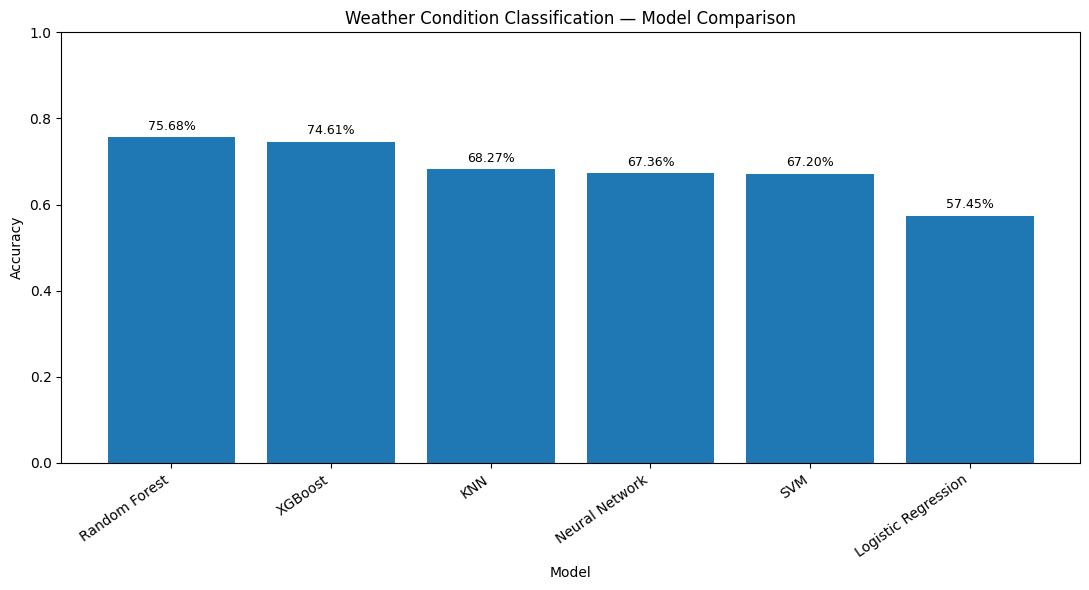

In [24]:
# ============================================================
# 23. Model Comparison Visualization
# ============================================================
plt.figure(figsize=(11, 6))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Weather Condition Classification — Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, results_df["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## 17. Detailed Evaluation for the Completed Experiment

Accuracy alone can hide poor performance on rare weather conditions. For portfolio-quality analysis, the next step is to inspect a classification report and confusion matrix for the selected models.

The following cell reports the metrics using the predictions produced above. It does not assume a single model is universally best; the goal is to expose the trade-offs clearly.

In [25]:
# ============================================================
# 24. Detailed Classification Reports
# ============================================================
class_ids = np.arange(len(label_encoder.classes_))

for name, y_pred in model_predictions.items():
    print("=" * 90)
    print(name)
    print("=" * 90)
    print(
        classification_report(
            y_test,
            y_pred,
            labels=class_ids,
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )


Logistic Regression
                       precision    recall  f1-score   support

                   0.       0.00      0.00      0.00         6
       Broken clouds.       0.39      0.14      0.21       518
               Clear.       0.56      0.68      0.62      4843
                Cool.       0.40      0.22      0.29         9
           Dense fog.       0.00      0.00      0.00         2
             Drizzle.       0.00      0.00      0.00        17
           Duststorm.       0.33      0.12      0.18         8
       Extremely hot.       0.00      0.00      0.00         6
                 Fog.       0.83      0.91      0.87      1579
                Haze.       0.58      0.58      0.58      1764
                 Hot.       0.00      0.00      0.00         2
           Light fog.       0.00      0.00      0.00         5
          Light rain.       0.20      0.01      0.02        93
                Mild.       0.00      0.00      0.00         4
More clouds than sun.       0.00  

## 17. XGBoost Feature Importance

Tree-based feature importance helps explain which weather variables contribute most to the tuned XGBoost model. This is a model-specific interpretation, not proof of causation.

Top XGBoost Feature Importances


,Feature,Importance
1,Visibility,0.244564
0,Humidity,0.140110
6,hour_cos,0.131342
9,Wind Speed(km/h),0.056921
20,hour_sin,0.036534
2,Temperature(Â°C),0.034316
11,Lag_1_Pressure(mbar),0.033067
4,Lag_1_Temperature(Â°C),0.029414
13,Pressure(mbar),0.027087
3,Lag_3_Temperature(Â°C),0.025510


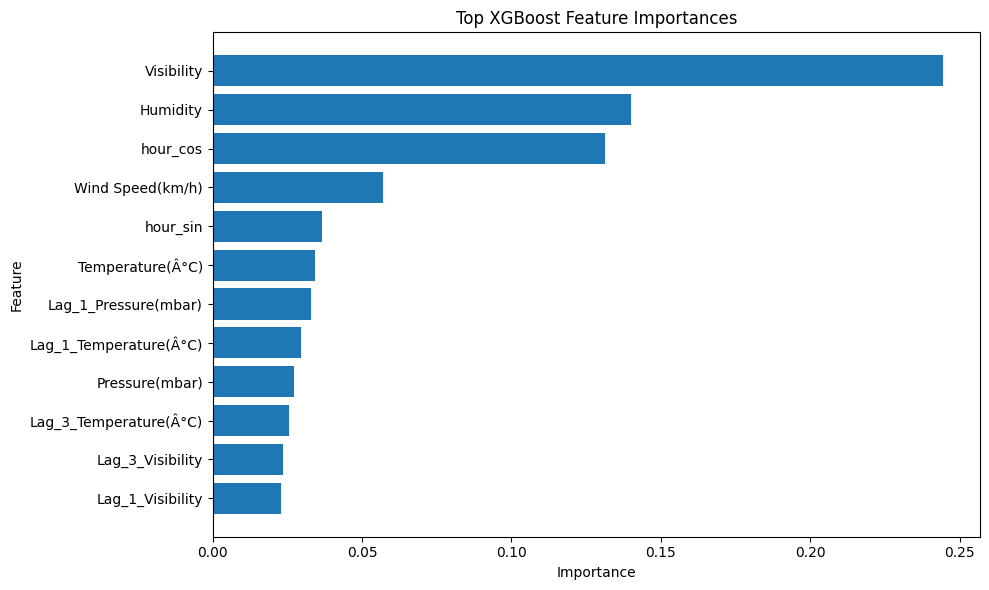

In [27]:
# ============================================================
# 25. XGBoost Feature Importance
# ============================================================
if "XGBoost" in trained_models:
    xgb_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": trained_models["XGBoost"].feature_importances_,
    }).sort_values("Importance", ascending=False)
    print('Top XGBoost Feature Importances')
    display(xgb_importance.head(15))

    plt.figure(figsize=(10, 6))
    top = xgb_importance.head(12).sort_values("Importance")
    plt.barh(top["Feature"], top["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top XGBoost Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost was not trained successfully; feature importance is unavailable.")
